# Modelo de entrenamiento triaje

## Limpieza de datos triaje

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

In [2]:
ruta = '../datos/mimic-iv-ed-demo-2.2/mimic-iv-ed-demo-2.2/ed/triage.csv.gz'

triaje = pd.read_csv(ruta)

df = triaje[triaje['acuity'].notna() & triaje['pain'].notna() & triaje['temperature'].notna() & triaje['heartrate'].notna() & triaje['o2sat'].notna()].drop(columns=['subject_id', 'stay_id', 'chiefcomplaint'])

df['pain'] = df['pain'].replace({'UA':0, 'unable':0, 'uta':0, 'ett':0, 'o':0,})

df['pain'] = pd.to_numeric(df['pain'])

df['acuity'] = np.round(df['acuity'] / 5)

df

,temperature,heartrate,resprate,o2sat,sbp,dbp,pain,acuity
17,98.8,72.0,18.0,90.0,98.0,48.0,13,0.0
18,97.8,115.0,20.0,99.0,92.0,42.0,0,0.0
19,98.1,95.0,18.0,99.0,149.0,74.0,0,0.0
20,98.3,57.0,18.0,99.0,161.0,68.0,0,0.0
21,97.0,81.0,18.0,99.0,161.0,55.0,0,0.0
...,...,...,...,...,...,...,...,...
217,97.7,111.0,15.0,100.0,133.0,79.0,3,1.0
218,98.4,106.0,18.0,95.0,131.0,76.0,5,1.0
219,96.8,78.0,16.0,95.0,186.0,66.0,8,1.0
220,98.6,108.0,18.0,95.0,143.0,61.0,7,1.0


## Preparación de los datos

In [ ]:
X = df[['temperature', 'heartrate','resprate', 'o2sat', 'sbp', 'dbp','pain']].astype({
    'temperature': 'float32',
    'heartrate': 'float32',
    'resprate': 'float32',
    'o2sat': 'float32',
    'sbp': 'float32',
    'dbp': 'float32',
    'pain': 'float32'
}).to_numpy()

print(f'La forma de X es: {X.shape}')

# DONE: selecciona la etiqueta y conviértela a float32
# Pista: utiliza una lista de columnas para conservar la segunda dimensión
y = df[['acuity']].to_numpy(dtype=np.float32)

print(X[:20])

y = y.ravel()

print(f'La forma de y es: {y.shape}')

La forma de X es: (190, 7)
[[ 98.8  72.   18.   90.   98.   48.   13. ]
 [ 97.8 115.   20.   99.   92.   42.    0. ]
 [ 98.1  95.   18.   99.  149.   74.    0. ]
 [ 98.3  57.   18.   99.  161.   68.    0. ]
 [ 97.   81.   18.   99.  161.   55.    0. ]
 [ 97.3  80.   18.   99.  138.   78.    4. ]
 [ 96.6  55.   16.   99.  159.   80.    0. ]
 [100.1 128.   20.   99.  151.   73.    0. ]
 [ 97.3  43.   16.   99.  140.  100.    0. ]
 [ 97.4  66.   18.   99.  111.   68.    8. ]
 [ 98.   70.   16.   99.  155.   86.    0. ]
 [ 98.7 118.   22.   99.  131.   89.   10. ]
 [ 97.1  98.   15.   99.  102.   59.    3. ]
 [100.2 106.   20.   99.  142.   73.    5. ]
 [ 97.7  79.   20.   99.  100.   58.    0. ]
 [ 97.  126.   22.   99.  136.   68.    0. ]
 [ 97.8  52.   17.   99.  134.   57.    0. ]
 [ 97.6  96.   16.   94.  121.   65.    7. ]
 [ 99.1  84.   18.   94.  139.   65.    0. ]
 [ 99.4  80.   18.   98.  158.   72.   10. ]]
La forma de y es: (190, 1)


## División entrenamiento y prueba

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


rf = RandomForestClassifier(n_estimators=100, random_state=42)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

accuracy = rf.score(X_test, y_test)
print("Accuracy:", accuracy)    

resultados = cross_val_score(rf, X, y, cv=5, scoring='accuracy')

Accuracy: 0.6842105263157895


In [39]:
import pickle

# Save the model to disk
with open("rf.pkl", "wb") as file:
  pickle.dump(rf, file)

# Load the model
with open("rf.pkl", "rb") as file:
  loaded_model = pickle.load(file)

accuracy = loaded_model.score(X_test, y_test)
print("Accuracy:", accuracy)    

resultados = cross_val_score(loaded_model, X, y, cv=5, scoring='accuracy')

Accuracy: 0.6842105263157895


## Pruebas de modelo

In [34]:
# DONE: crea la capa de normalización
normalizator = tf.keras.layers.Normalization(axis=-1)
tf.keras.utils.set_random_seed(42)

# DONE: adapta la capa utilizando X_train
normalizator.adapt(X_train)
X_train_normal = normalizator(X_train)

model = tf.keras.Sequential([
    tf.keras.Input(shape=(7,)),
    normalizator,
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_binary_accuracy',
    patience=3,
    restore_best_weights=True
)

optimizer = tf.keras.optimizers.AdamW(
    learning_rate=0.01
)

loss = tf.keras.losses.BinaryCrossentropy()

metric = tf.keras.metrics.BinaryAccuracy()

model.compile(
    optimizer=optimizer,
    loss=loss,
    metrics=[metric]
)

history = model.fit(
    X_train, y_train,
    epochs=25,
    batch_size=8,
    verbose=0,
    callbacks=[early_stopping],
    validation_data=(X_test, y_test)
)

test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print(f'Valor de loss: {test_loss}')
print(f'Valor de accuracy: {test_accuracy}')

Valor de loss: 0.6414291262626648
Valor de accuracy: 0.6315789222717285


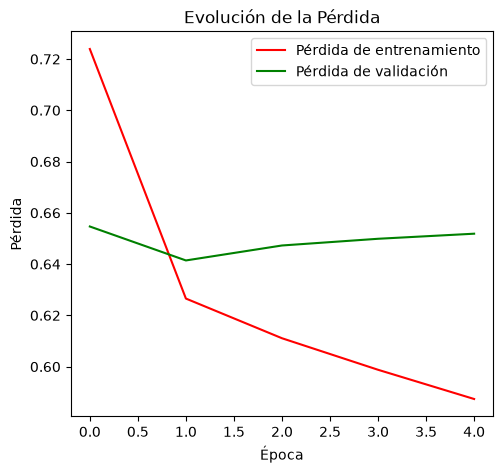

In [40]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(
    history.history["loss"],
    label="Pérdida de entrenamiento",
    color="red"
)
plt.plot(
    history.history["val_loss"],
    label="Pérdida de validación",
    color="green"
)
plt.xlabel("Época")
plt.ylabel("Pérdida")
plt.title("Evolución de la Pérdida")
plt.legend()

plt.show()